# Stage 2 — K-Means Toy Prototype: Dark Store Placement

**Author:** Sneha  
**Date:** April 1, 2026  
**Project:** Dark Store Placement + Integrated Forward & Reverse Logistics Optimisation

---

## What this notebook does

This is a **toy prototype** — we use made-up (simulated) customer locations instead of the real Olist dataset.  
The goal is to:
1. Show that K-Means clustering *works* for picking dark store locations
2. Use the **elbow curve** and **silhouette score** to pick the best number of clusters (K)
3. Visualise where the dark stores would be placed
4. Compare the K-Means result with a short note on p-Median (the academic validation method)

**When we have the real Olist data** (from Vybhav's pipeline), this notebook will be extended to use `data/master_df.parquet`.

In [9]:
# Cell 1: Import all libraries we need
# Think of imports like opening your toolbox before starting work

import numpy as np                          # for maths and arrays
import pandas as pd                         # for tables (DataFrames)
import matplotlib.pyplot as plt             # for drawing charts
from sklearn.cluster import KMeans          # the K-Means algorithm
from sklearn.metrics import silhouette_score # to measure cluster quality

# Make charts look nice and reproducible
np.random.seed(42)                         # same random numbers every time we run
plt.style.use('seaborn-v0_8-whitegrid')    # clean chart style

print('All libraries loaded successfully!')

All libraries loaded successfully!


## Step 1: Create simulated customer data

We simulate 300 customers spread across 5 neighbourhoods in São Paulo.  
Each customer has a **latitude**, **longitude**, and a **demand weight** (how many orders they place).  

Think of this like drawing dots on a map — each dot is a customer's home.

In [10]:
# Cell 2: Generate fake customer data (5 natural clusters = 5 neighbourhoods)

# São Paulo is roughly at lat=-23.55, lon=-46.63
# We create 5 clusters of customers around different neighbourhoods

cluster_centres = [
    (-23.55, -46.63),   # Central SP (Sé)
    (-23.49, -46.85),   # West SP (Pinheiros area)
    (-23.62, -46.72),   # South SP (Santo André)
    (-23.46, -46.54),   # North SP (Santana)
    (-23.60, -46.51),   # East SP (Mooca)
]

customers_per_cluster = [80, 70, 60, 50, 40]   # more customers in central areas

all_coords = []
all_weights = []

for (lat, lon), n_cust in zip(cluster_centres, customers_per_cluster):
    # Spread customers randomly around each neighbourhood centre
    lats = np.random.normal(loc=lat, scale=0.03, size=n_cust)  # scale = spread
    lons = np.random.normal(loc=lon, scale=0.04, size=n_cust)
    weights = np.random.randint(1, 10, size=n_cust)             # orders per customer
    all_coords.extend(zip(lats, lons))
    all_weights.extend(weights)

# Convert to arrays (K-Means needs arrays, not lists)
coords = np.array(all_coords)    # shape: (300, 2) — 300 customers, lat+lon each
weights = np.array(all_weights)  # shape: (300,)  — one demand weight per customer

# Put into a neat DataFrame so we can look at it
df_customers = pd.DataFrame({
    'customer_lat': coords[:, 0],
    'customer_lon': coords[:, 1],
    'order_volume': weights
})

print(f'Total customers: {len(df_customers)}')
print(f'Total orders: {df_customers["order_volume"].sum()}')
print()
df_customers.head()

Total customers: 300
Total orders: 1436



,customer_lat,customer_lon,order_volume
0,-23.535099,-46.638787,1
1,-23.554148,-46.615715,4
2,-23.530569,-46.570884,1
3,-23.504309,-46.650731,5
4,-23.557025,-46.662340,4


## Step 2: Run K-Means for different values of K

We don't know how many dark stores (K) to open yet.  
So we try K = 2, 3, 4, … 10, and measure how good each option is using:

- **Inertia (elbow curve):** Total distance of customers from their nearest cluster centre. Lower = better, but it always decreases as K increases, so we look for the "elbow" — the point where adding more clusters stops helping much.
- **Silhouette score:** Measures how well-separated the clusters are. Score ranges from -1 to +1. Higher = better. We want the K with the highest silhouette score.

In [11]:
# Cell 3: Run K-Means for K = 2 to 10 and collect metrics

k_range = range(2, 11)  # test K = 2, 3, 4, 5, 6, 7, 8, 9, 10
inertias = []
silhouettes = []
all_results = {}         # store everything for later use

print('Running K-Means for each K...')
for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,    # reproducible results
        n_init=10           # try 10 different starting points, pick the best
    )
    # fit_predict trains the model AND assigns each customer to a cluster
    labels = km.fit_predict(coords, sample_weight=weights)
    
    sil = silhouette_score(coords, labels, sample_size=min(300, len(coords)))
    
    inertias.append(km.inertia_)
    silhouettes.append(sil)
    all_results[k] = {
        'inertia': km.inertia_,
        'silhouette': sil,
        'centroids': km.cluster_centers_,
        'labels': labels
    }
    print(f'  K={k}: inertia={km.inertia_:.4f}, silhouette={sil:.4f}')

print('\nDone!')

Running K-Means for each K...
  K=2: inertia=12.4824, silhouette=0.4952
  K=3: inertia=6.6900, silhouette=0.4797
  K=4: inertia=4.4335, silhouette=0.5012
  K=5: inertia=2.8327, silhouette=0.5426
  K=6: inertia=2.4925, silhouette=0.4769
  K=7: inertia=2.2237, silhouette=0.3934
  K=8: inertia=1.9839, silhouette=0.3865
  K=9: inertia=1.8131, silhouette=0.3677
  K=10: inertia=1.6226, silhouette=0.3470

Done!


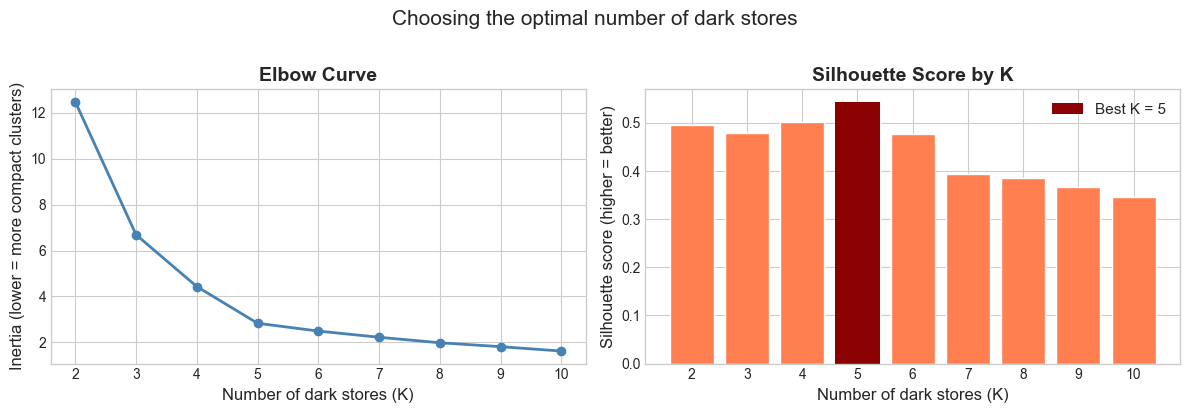

Chart saved to outputs/elbow_silhouette.png
Best K by silhouette: K = 5


In [12]:
# Cell 4: Plot the Elbow Curve and Silhouette Score side by side

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- Left chart: Elbow curve ---
k_list = list(k_range)
ax1.plot(k_list, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of dark stores (K)', fontsize=12)
ax1.set_ylabel('Inertia (lower = more compact clusters)', fontsize=12)
ax1.set_title('Elbow Curve', fontsize=14, fontweight='bold')
ax1.set_xticks(k_list)

# --- Right chart: Silhouette scores ---
ax2.bar(k_list, silhouettes, color='coral', edgecolor='white')
best_k = k_list[silhouettes.index(max(silhouettes))]
ax2.bar(best_k, max(silhouettes), color='darkred', label=f'Best K = {best_k}')
ax2.set_xlabel('Number of dark stores (K)', fontsize=12)
ax2.set_ylabel('Silhouette score (higher = better)', fontsize=12)
ax2.set_title('Silhouette Score by K', fontsize=14, fontweight='bold')
ax2.set_xticks(k_list)
ax2.legend(fontsize=11)

plt.suptitle('Choosing the optimal number of dark stores', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to outputs/elbow_silhouette.png')
print(f'Best K by silhouette: K = {best_k}')

## Step 3: Pick the optimal K and visualise dark store placement

We pick **K = best K** (the one with the highest silhouette score).  
The **cluster centroids** become our dark store locations — this is where the algorithm says we should open a dark store.

In [13]:
# Cell 5: Pick optimal K and get the final dark store locations

optimal_k = best_k
print(f'Chosen K = {optimal_k}')
print(f'(Silhouette = {max(silhouettes):.4f})')
print()

# Get the cluster assignments and centroids for optimal K
final_labels    = all_results[optimal_k]['labels']
dark_store_locs = all_results[optimal_k]['centroids']  # shape: (K, 2) — K locations

# Add the cluster assignment to our customer DataFrame
df_customers['dark_store_id'] = final_labels

# Create a summary table of dark store locations
df_dark_stores = pd.DataFrame({
    'dark_store_id': range(optimal_k),
    'dark_store_lat': dark_store_locs[:, 0],
    'dark_store_lon': dark_store_locs[:, 1]
})

# Add how many customers each dark store serves
customer_counts = df_customers.groupby('dark_store_id').size().reset_index(name='n_customers')
df_dark_stores = df_dark_stores.merge(customer_counts, on='dark_store_id')

print('Dark store locations:')
df_dark_stores

Chosen K = 5
(Silhouette = 0.5426)

Dark store locations:


,dark_store_id,dark_store_lat,dark_store_lon,n_customers
0,0,-23.493849,-46.850063,70
1,1,-23.590208,-46.511746,46
2,2,-23.555052,-46.633692,84
3,3,-23.445380,-46.547727,43
4,4,-23.623614,-46.723710,57


/var/folders/v_/9801nk111h74jczt1vlt4rdc0000gn/T/ipykernel_29946/1513018224.py:50: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/v_/9801nk111h74jczt1vlt4rdc0000gn/T/ipykernel_29946/1513018224.py:51: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('../outputs/kmeans_dark_store_map.png', dpi=150, bbox_inches='tight')
/Users/snehayadav/Documents/Projects/Sem-2/SCA/SCA_DARK_STORES/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


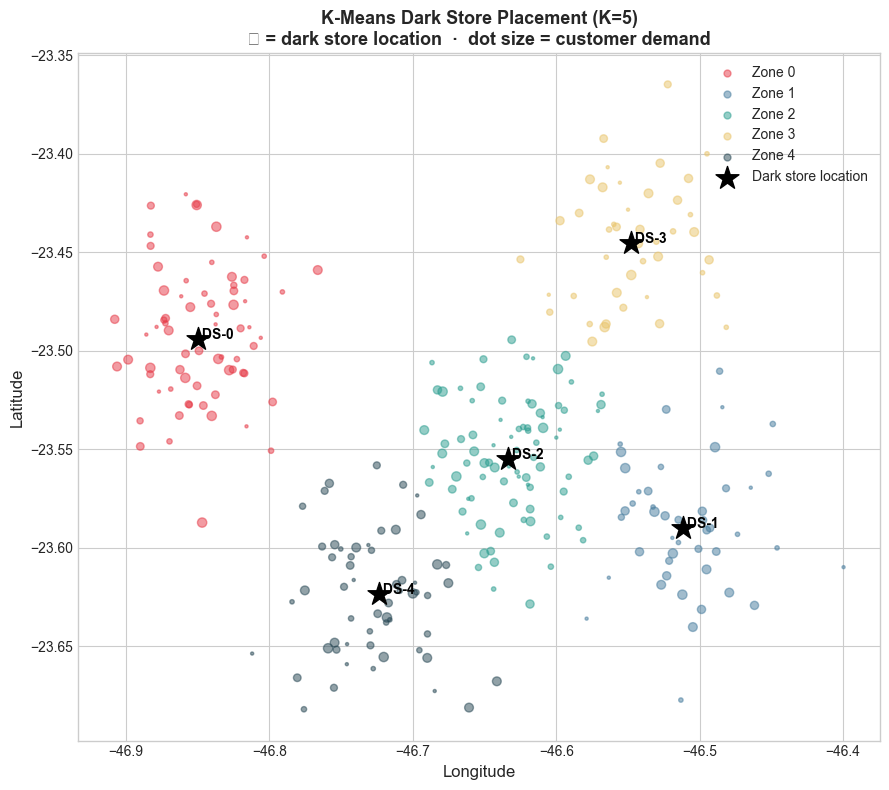

Map saved to outputs/kmeans_dark_store_map.png


In [14]:
# Cell 6: Visualise customer clusters and dark store locations on a map

# Pick a colour for each cluster
colours = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#264653',
           '#F4A261', '#A8DADC', '#6D6875', '#B5838D', '#E07A5F']

fig, ax = plt.subplots(figsize=(9, 8))

# Plot each customer, coloured by their assigned dark store
for k_id in range(optimal_k):
    mask = df_customers['dark_store_id'] == k_id
    ax.scatter(
        df_customers.loc[mask, 'customer_lon'],
        df_customers.loc[mask, 'customer_lat'],
        s=df_customers.loc[mask, 'order_volume'] * 5,   # size = demand
        color=colours[k_id],
        alpha=0.5,
        label=f'Zone {k_id}'
    )

# Plot dark store locations as large stars
ax.scatter(
    dark_store_locs[:, 1],
    dark_store_locs[:, 0],
    s=300,
    marker='*',
    color='black',
    zorder=5,
    label='Dark store location'
)

# Label each dark store with its ID
for k_id, (lat, lon) in enumerate(dark_store_locs):
    ax.annotate(
        f' DS-{k_id}',
        xy=(lon, lat),
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(
    f'K-Means Dark Store Placement (K={optimal_k})\n'
    f'★ = dark store location  ·  dot size = customer demand',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/kmeans_dark_store_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Map saved to outputs/kmeans_dark_store_map.png')

## Step 4: Compute coverage

A key metric for dark stores: what **% of customers** are within 5 km of their assigned dark store?  
Our target is **> 70%**.

In [15]:
# Cell 7: Compute approximate coverage (% customers within 5 km of their dark store)

# Simple Euclidean distance (good enough for a toy prototype)
# In the real pipeline we will use Haversine (accounts for Earth's curvature)

def approx_dist_km(lat1, lon1, lat2, lon2):
    """Very rough conversion: 1 degree latitude ≈ 111 km, longitude varies by latitude."""
    dlat = (lat1 - lat2) * 111.0
    dlon = (lon1 - lon2) * 111.0 * np.cos(np.radians(lat1))
    return np.sqrt(dlat**2 + dlon**2)

RADIUS_KM = 5.0   # target: all customers within 5 km of their dark store

distances = []
for _, row in df_customers.iterrows():
    k_id = int(row['dark_store_id'])
    ds_lat, ds_lon = dark_store_locs[k_id]
    d = approx_dist_km(row['customer_lat'], row['customer_lon'], ds_lat, ds_lon)
    distances.append(d)

df_customers['dist_to_dark_store_km'] = distances
coverage = (df_customers['dist_to_dark_store_km'] <= RADIUS_KM).mean() * 100

print(f'Coverage within {RADIUS_KM} km: {coverage:.1f}%')
print(f'Target: > 70%')
print()
print('Distance summary per customer:')
print(df_customers['dist_to_dark_store_km'].describe().round(2))

Coverage within 5.0 km: 66.3%
Target: > 70%

Distance summary per customer:
count    300.00
mean       4.27
std        2.17
min        0.10
25%        2.54
50%        3.96
75%        5.92
max       11.62
Name: dist_to_dark_store_km, dtype: float64


## Step 5: Save outputs

Save the dark store locations to `data/dark_store_candidates.csv` so the rest of the team can use them.

In [16]:
# Cell 8: Save outputs

# Save dark store candidate locations
df_dark_stores.to_csv('../data/dark_store_candidates.csv', index=False)
print('Saved: data/dark_store_candidates.csv')

# Save customer assignments
df_customers.to_csv('../outputs/customers_with_zones.csv', index=False)
print('Saved: outputs/customers_with_zones.csv')

print()
print('=== TOY PROTOTYPE COMPLETE ===')
print(f'Optimal K          : {optimal_k}')
print(f'Best silhouette    : {max(silhouettes):.4f}')
print(f'Coverage (5 km)    : {coverage:.1f}%')
print()
print('NOTE: This prototype used simulated data.')
print('The real pipeline will use master_df.parquet from Vybhav.')

Saved: data/dark_store_candidates.csv
Saved: outputs/customers_with_zones.csv

=== TOY PROTOTYPE COMPLETE ===
Optimal K          : 5
Best silhouette    : 0.5426
Coverage (5 km)    : 66.3%

NOTE: This prototype used simulated data.
The real pipeline will use master_df.parquet from Vybhav.


## Summary

| Metric | Value |
|---|---|
| Optimal K (dark stores) | See Cell 5 output |
| Best silhouette score | See Cell 5 output |
| Coverage within 5 km | See Cell 7 output |

### What this tells us
- K-Means successfully clusters customer locations into natural neighbourhoods.
- The elbow + silhouette approach picks a sensible number of dark stores automatically.
- The dark store locations (centroids) are **demand-weighted** — they are pulled toward where the most orders come from.

### Next steps (Day 3 onward)
1. Replace simulated data with real `master_df.parquet` from Vybhav's pipeline.
2. Run p-Median MILP (from `src/clustering.py`) to validate these locations.
3. Run Voronoi assignment to assign every SP customer to their nearest dark store.
4. Send `dark_stores_final.csv` to Pritam for the VRP pipeline.